#Machine Learning Course Work 2- Image Classification.
This coursework has been done by -

* Student ID : **A00057300**
* Task: Neural Network for Image Classification using Transfer Learning (MobileNetV2)
* Video Demonstration :https://roehamptonprod-my.sharepoint.com/:f:/g/personal/hossainm13_roehampton_ac_uk/IgAAcDMN1zFnT50RXA2K7sR2AS_xRbCK4jqfciSwzJ3hAr4?e=M5Awew
* **AI Declaration** : I used ChatGPT solely to support my understanding of machine-learning concepts relevant to this image-classification project. The tool was used for educational clarification only, with prompts such as “What is a convolutional neural network?”, “How does data augmentation work?”, and “How do I interpret accuracy, precision, recall, and confusion matrices?”. All coding, experimentation, model development, and analysis presented in this coursework are my own original work.

# Required Libraries

In [ ]:
#Importing Required Libraries

#core python libraries for data handling and visualisation
import os
import random
import shutil                    # coping or moving image files
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg #used for reading image files



#additional data utilities
from scipy.io import loadmat                          # used for loading imagelabels.mat and setid.mat
from PIL import Image                                 # used for opening  raw images
from sklearn.model_selection import train_test_split  # splitting dataset manually
from sklearn.metrics import confusion_matrix          # for evaluation
from sklearn.metrics import classification_report     # for evaluation

#TensorFlow / Keras Modules
from tensorflow.keras.preprocessing.image import ImageDataGenerator #loading and preprocessing images
from tensorflow.keras.applications import MobileNetV2               #pretrained CNN model
from tensorflow.keras import layers, models                         # building neural network layers
from tensorflow.keras.optimizers import Adam                        #Optimizer

#Data Understanding

In [ ]:
#downloading the oxford 102Flower Dataset directly in colab
!wget https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz #tar-gzip format file as .tgz


#downloading the flower labels (1-102)
!wget https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat #matlab file as .mat


--2025-11-19 15:30:33--  https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/flowers/102/102flowers.tgz [following]
--2025-11-19 15:30:33--  https://thor.robots.ox.ac.uk/flowers/102/102flowers.tgz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 344862509 (329M) [application/octet-stream]
Saving to: ‘102flowers.tgz’

102flowers.tgz      100%[===================>] 328.89M  39.4MB/s    in 9.2s    

2025-11-19 15:30:43 (35.7 MB/s) - ‘102flowers.tgz’ saved [344862509/344862509]

--2025-11-19 15:30:43--  https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels

Here, **wget** command was used to download files straight pulled from the **Oxford Visual Geometry Group website** into our colab environment
and **"!"** tells tells colab to execute the command in the lynux terminal instead of python.

In [ ]:
#extracting the compressed image 102flower dataset.


#The dataset is downloaded as a .tgz archieve.
#and neural network needs individual image file as it learn pattern by looking one image at a time to get each images own varriations.

!tar -xvzf 102flowers.tgz
print('Oxford 102 flowers downloaded and extracted')

Streaming output truncated to the last 5000 lines.
jpg/image_00062.jpg
jpg/image_05821.jpg
jpg/image_03712.jpg
jpg/image_01142.jpg
jpg/image_03033.jpg
jpg/image_05760.jpg
jpg/image_02732.jpg
jpg/image_00183.jpg
jpg/image_05264.jpg
jpg/image_03778.jpg
jpg/image_07061.jpg
jpg/image_04468.jpg
jpg/image_00676.jpg
jpg/image_07610.jpg
jpg/image_02192.jpg
jpg/image_05112.jpg
jpg/image_05638.jpg
jpg/image_00053.jpg
jpg/image_02451.jpg
jpg/image_05857.jpg
jpg/image_08033.jpg
jpg/image_03902.jpg
jpg/image_07494.jpg
jpg/image_02357.jpg
jpg/image_05496.jpg
jpg/image_04496.jpg
jpg/image_07538.jpg
jpg/image_01801.jpg
jpg/image_00326.jpg
jpg/image_07644.jpg
jpg/image_01199.jpg
jpg/image_01168.jpg
jpg/image_07020.jpg
jpg/image_05006.jpg
jpg/image_03484.jpg
jpg/image_02825.jpg
jpg/image_04549.jpg
jpg/image_02011.jpg
jpg/image_04360.jpg
jpg/image_06847.jpg
jpg/image_07695.jpg
jpg/image_03540.jpg
jpg/image_08058.jpg
jpg/image_01230.jpg
jpg/image_00096.jpg
jpg/image_01517.jpg
jpg/image_07640.jpg
jpg/image

Here, **"!"** runs as linux command and tells colab that the following lines are not python but run in terminal
* Here, .tgz file contains all the flower images in a compressed format
*tar-xvgf command unpacks all the images into the current directory

In [ ]:
#loading the flower labels from .mat file


#loading matlab file (which is containing (1-102) classs labels for each image)
labels_data=loadmat('imagelabels.mat')

# extracting the actual label list
labels=labels_data['labels'][0]


#checking the lengths of outputs
print("total images",len(labels))

total images 8189


So, here the code loads the flower label category that come with imagelabel.mat dataset. As, matlab stores label inside a nested structure so we extracted the nested array and flattened it into a simple 1-D array. After flattening we end up having one label per image ranging 1 to 102.

In [ ]:
#checking labels
print('min labels',min(labels))
print('max labels',max(labels))

min labels 1
max labels 102


so, it is confirmed that label dataset starts from 1 and highest label number 102. So, labels were loaded properly


In [ ]:
#to know the image folder name and pattern
!ls


102flowers.tgz	imagelabels.mat  jpg  sample_data


In [ ]:
#viewing some of file name pattern
!ls jpg | head

image_00001.jpg
image_00002.jpg
image_00003.jpg
image_00004.jpg
image_00005.jpg
image_00006.jpg
image_00007.jpg
image_00008.jpg
image_00009.jpg
image_00010.jpg


In [ ]:
#Verifying the folder path and extracted image

folder="/content/jpg/" #the folder where all the .jpg files are stored

#listing(os.listdir) and sorting(sorted) all the images inside the folder
all_images=sorted(os.listdir(folder))


print('total images found:',len(all_images)) #printing total number of files found
#printing few file names to verify pattern
print('first 5 images:',all_images[:5])

total images found: 8189
first 5 images: ['image_00001.jpg', 'image_00002.jpg', 'image_00003.jpg', 'image_00004.jpg', 'image_00005.jpg']


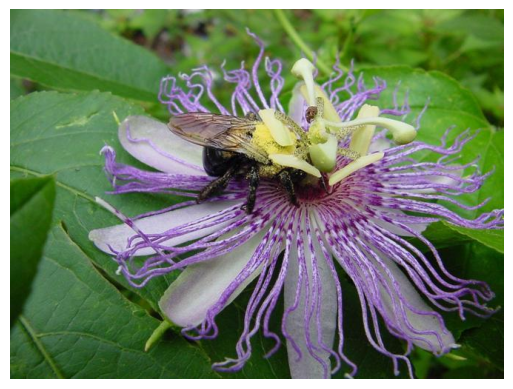

In [ ]:
#visualising a sample.

#choosing a image index to preview
image_number=40

#building the exact file name
file_name=f"image_{image_number:05d}.jpg" # :05d means here always 5 digits with zeros in front
full_path=folder+file_name #combining the folder and file name to get the full path
img=mpimg.imread(full_path)

#showing the image
plt.imshow(img)
plt.axis('off')
plt.show()

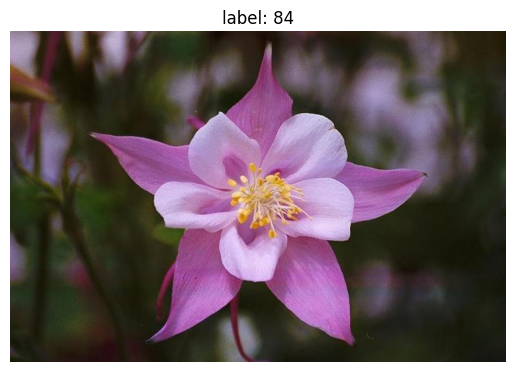

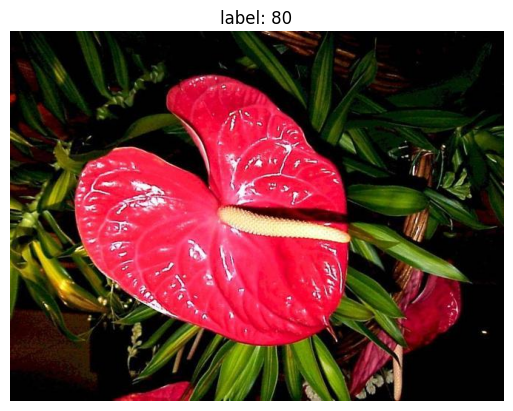

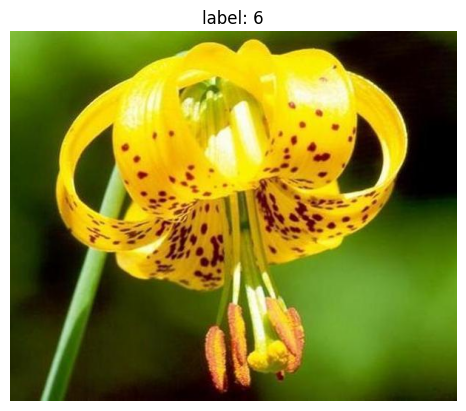

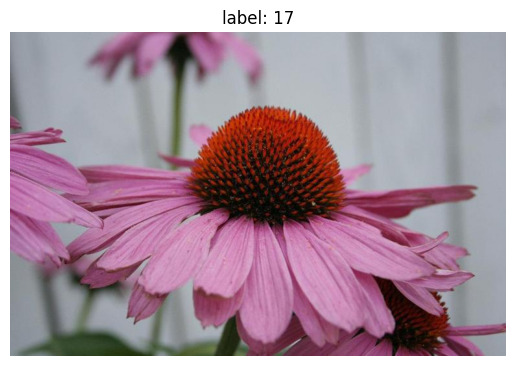

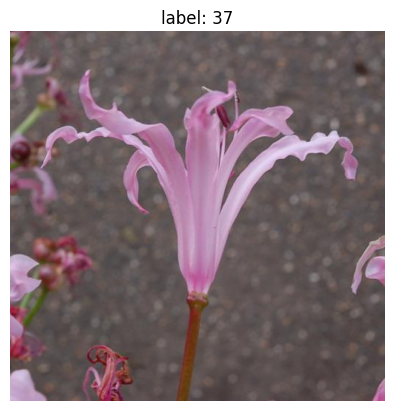

In [ ]:
#Visualising multiple random sample images

# Showing 5 random images from the dataset
for i in range(5):

  # Selecting a random image index between 1 and the total number of labels (8189)
  image_number = random.randint(1, len(labels))

  # Constructing the filename with zero-padding (:05d ensures 5 digits, e.g., 00040)
  file_name = f"image_{image_number:05d}.jpg"

  # Full file path to locate the image
  full_path = folder + file_name

  # Loading the image into a NumPy array
  img = mpimg.imread(full_path)

  # Display the image
  plt.imshow(img)
  plt.axis('off')
  # labels are 1-based originally, so we use (image_number - 1) to match Python indexing
  plt.title("label: " + str(labels[image_number - 1]))

  plt.show()


here, this code randomly selects 5 images and displays them
* every images were converted to their original file name format example: **"image_00001.jpg"**
* combined them with image directory to get the exact path
* and loaded them using **mping.imread() ** , it converts it into a NumPy array for computer's readability
* the visuals confirm it

In [ ]:
#checking image size


all_min=[] #will store minimum pixel values from sampled images
all_max=[] #will store maximum pixel values from sampled images


for i in range(10): #checking 10 random numbers

  #selecting a random number indexing between 1 and total number of labels
  image_number=random.randint(1,len(labels))

  #building correct file name with zero padding
  file_name=f"image_{image_number:05d}.jpg"
  full_path=folder+file_name

  #loading image once
  img=Image.open(full_path)
  #converting the loaded image into a numpy array
  arr=np.array(img)

  print(file_name,"-----shape:", arr.shape)
  print("dtype",arr.dtype)

  #storing min/max for this image
  all_min.append(np.min(arr))
  all_max.append(np.max(arr))

print ("pixel range (across 10 images):", min(all_min), "to", max(all_max))

image_00477.jpg -----shape: (500, 734, 3)
dtype uint8
image_01550.jpg -----shape: (501, 773, 3)
dtype uint8
image_03060.jpg -----shape: (500, 750, 3)
dtype uint8
image_07105.jpg -----shape: (500, 514, 3)
dtype uint8
image_00057.jpg -----shape: (500, 667, 3)
dtype uint8
image_00909.jpg -----shape: (500, 667, 3)
dtype uint8
image_03341.jpg -----shape: (500, 744, 3)
dtype uint8
image_03333.jpg -----shape: (667, 500, 3)
dtype uint8
image_01356.jpg -----shape: (500, 752, 3)
dtype uint8
image_07396.jpg -----shape: (594, 500, 3)
dtype uint8
pixel range (across 10 images): 0 to 255


**So, we confirmed--**
* sample images have consistent shape,RGB formats and pixel value within expectation (0-255)
* as the dataset is organised we can get

# Data Preprocessing

In [ ]:
#converting matlab 1-based labels to python 0-based labels


#loading matlab files as .mat files( which stores image index from 1-102)
labels = loadmat("imagelabels.mat")["labels"][0]

#converting 0 based python indexing
labels = labels - 1 # index becomes 0 to 101
print('after label fix:')
print('min label:', min(labels))
print('max label', max(labels))


after label fix:
min label: 0
max label 101


In [ ]:
#checking if the labels and images match now

if len(labels)==len(all_images): #length of labels array with number of image files must match
  print('labels and images count match')
else:
  print('labels and images do not match')

labels and images count match


In [ ]:
#double checking the image-label alignment with filenames

for check in range(10): #selecting random 10 images
  image_number=random.randint(0,len(labels)) #from index 0 to 8188
  expected_filename=f"image_{image_number+1:05d}.jpg"

  actual_filename=all_images[image_number]

  print(image_number,"expected name:", expected_filename, "| actual name", actual_filename)


5646 expected name: image_05647.jpg | actual name image_05647.jpg
1183 expected name: image_01184.jpg | actual name image_01184.jpg
6690 expected name: image_06691.jpg | actual name image_06691.jpg
4431 expected name: image_04432.jpg | actual name image_04432.jpg
2991 expected name: image_02992.jpg | actual name image_02992.jpg
7042 expected name: image_07043.jpg | actual name image_07043.jpg
5324 expected name: image_05325.jpg | actual name image_05325.jpg
4252 expected name: image_04253.jpg | actual name image_04253.jpg
6328 expected name: image_06329.jpg | actual name image_06329.jpg
162 expected name: image_00163.jpg | actual name image_00163.jpg


In [ ]:
#generating a list of all images indices
indicies=list(range(len(all_images)))
print('total indicies:', len(indicies))


total indicies: 8189


this created a list of numbers representing each image. so, that we can use it later to split the dataset safely into training ,validation and testing sets.

In [ ]:
#spliting the dataset into test/train/validation dataset


#first split( 80% data for training, 20% kept seperate)
train_idx, temp_idx=train_test_split(indicies, test_size=0.2, random_state=42)

#In the first split that 20% dataset kept aside splitted again equally in test dataset and validation dataset
val_idx,test_idx=train_test_split(temp_idx,test_size=0.5,random_state=42)

#printing out the size of the each splits
print('training',len(train_idx))
print('validation',len(val_idx))
print('test',len(test_idx))

# adding all splits to see the total number matches with the actual dataset.
#so we know dataset splitting was correct
print('total check:', len(train_idx)+len(val_idx)+len(test_idx))



training 6551
validation 819
test 819
total check: 8189


In [ ]:
#creating a folder structure for the splitted dataset

base_dir = "/content/flowers_clean" #main directory to keep our cleaned dataset
splits=['train', 'val', 'test'] #dataset partitions

for s in splits:
  for cls in range(102):
    path=f"{base_dir}/{s}/{cls}"
    os.makedirs(path, exist_ok=True)
print('folder structure created successfully!')


folder structure created successfully!


In [ ]:
#Inspecting data folder structure

main_folder= !ls /content/flowers_clean
train_class_folder=!ls /content/flowers_clean/train
sample_class_content=!ls /content/flowers_clean/train/0
print('folders in the main directory', main_folder)
print('class folders in the train directory', train_class_folder)
print('lsit contents in the sample (0) class directory', sample_class_content)


folders in the main directory ['test  train  val']
class folders in the train directory ['0    12  18  23  29  34  4   45  50  56  61  67  72  78  83  89  94', '1    13  19  24  3   35  40  46  51  57  62  68  73  79  84  9\t 95', '10   14  2   25  30  36  41  47  52  58  63  69  74  8\t 85  90  96', '100  15  20  26  31  37  42  48  53  59  64  7\t 75  80  86  91  97', '101  16  21  27  32  38  43  49  54  6\t 65  70  76  81  87  92  98', '11   17  22  28  33  39  44  5\t 55  60  66  71  77  82  88  93  99']
lsit contents in the sample (0) class directory []


This code verifies-
* folder structure has been created correctly
* also shows the class folder inside training directory.
* shows class folder (0) is empty as no image has been copied into it yet.

In [ ]:
#function to copy images into their correct split and class folder


def copy_images(indicies, split_name):
  for idx in indicies:

    #get the label for this image
    label=labels[idx]

    #get the correcponding file name
    img_name=all_images[idx]

    #full path to the source image inside the jpg folder
    src=f"/{folder}/{img_name}"

    #destination path
    dst=f"{base_dir}/{split_name}/{label}/{img_name}"

    #coping the image
    shutil.copy(src,dst)


here, the function **copy_images** takes a list of indices( representing any possible splits) and copies each image into its correct folder based on its label.
* it retrives **label, img_name**
* then points to the raw image in the jpg folder
* copies it to the destination path inside the appropriate split and class directory within **flowers_clean**

In [ ]:
#coping all the images into their corresponding splits
copy_images(train_idx, "train")
copy_images(val_idx, "val")
copy_images(test_idx, "test")

print("Train images copied!")
print("Validation images copied!")
print("Test images copied!")

Train images copied!
Validation images copied!
Test images copied!


In [ ]:
#checking total number of images inside the train split
total = 0  #variable to accumulate total images count
for cls in range(102):
    total += len(os.listdir(f"{base_dir}/train/{cls}")) #loop through all 102 class folders (0-101)


#displaying total number of training images
total


6551

Here,
* the total number of images inside all the training folders was checked.
* The code loops through each of the 102 class folders, counts the number of images in each one, and continuously adds the counts into the total variable.
After completing the loop, the final value of** total** represents the total number of training images.

In [ ]:
#preparing the raw images for training.

img_size = (224, 224)      # MobileNetV2 required input
batch_size = 32            #number of image processed in one batch

#ImageDataGenerator handles preprocessing automatically

datagen = ImageDataGenerator(rescale=1./255) #rescaled the pixel values from 0-255 to 0-1


This step sets up a data generator that will load images, resize them to 224*224, and scale their pixel values to the 0-1 range. This makes the images ready for training a MobileNetV2-based model.

In [ ]:
#creating the training data generator

train_gen = datagen.flow_from_directory(
    f"{base_dir}/train", #path to the training folder
    target_size=img_size, #resizing the image 224*224
    batch_size=batch_size, #number of images per batch
    class_mode='categorical'#one-hot encoded labels for 102 classes
)




Found 6551 images belonging to 102 classes.


In [ ]:
#creating the validation data generator

val_gen = datagen.flow_from_directory(
    f"{base_dir}/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 819 images belonging to 102 classes.


In [ ]:
#creating the test data generator

test_gen = datagen.flow_from_directory(
    f"{base_dir}/test",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle= False
)



Found 819 images belonging to 102 classes.


In [ ]:
#fetching a batch from the training generator
x, y = next(train_gen)
print(x.shape, y.shape)


(32, 224, 224, 3) (32, 102)


The variable x contains a batch of preprocessed images, resized to 224*224 and normalized to 0-1. The variable y contains the corresponding one-hot encoded labels for each image in the batch

#Model development

In [ ]:
#building the MobileNetV2 Transfer Learning Model


#loading mobilenetv2 pretraiened on ImageNet
base = MobileNetV2(
    input_shape=(224, 224, 3), #required input size
    include_top=False, #removing the classifier head so that we can add our own
    weights="imagenet" #using pre-trained Image Weights
)

# Freezing the base model so its weights do not update during training
base.trainable = False

#final model
model = models.Sequential([
    base,                                     #pretrained feature extractor
    layers.GlobalAveragePooling2D(),          #original features map to 1-D
    layers.Dense(256, activation='relu'),     #fully connected layer
    layers.Dropout(0.3),                       #regularization and prevent hak
    layers.Dense(102, activation='softmax')   # output layer for 102 flower classes
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 102)            │        26,214 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,612,134 (9.96 MB)

 Trainable params: 354,150 (1.35 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Here,
* MobileNetV2 was used a base model and keras layers/models to build my custom classifier suited for 102 class flower dataset
* model expects input of 224*224 pixel size and 3RGB channels.
* **include_top=False** removes MobileNetV2's original classifiers, means allows us to attach our own classification head.
* **weights="imagenet"** loads the pretrained weights obtained from traing on ImageNet, so the model already knows low-level patterns (edges, shapes, colors).
* **base.trainable = False** freezes all layers of MobileNetV2, so the remain unchanged during training and ensuring that only the newly added classifiers layer will learn from the 102flower dataset.
* Freezing the base model reduces training time, prevents overfitting, and stabilises learning, especially since the flower dataset is relatively small compared to ImageNet.
* The final architecture takes advantage of MobileNetV2's powerful pretrained feature extraction while learning task-specific decision boundaries through the added **Dense, Dropout, and softmax** layers


In [ ]:
#training the MobileNetV2 model

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.2877 - loss: 3.2962 - val_accuracy: 0.7753 - val_loss: 0.9610
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.7715 - loss: 0.8742 - val_accuracy: 0.8242 - val_loss: 0.6647
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.8615 - loss: 0.5136 - val_accuracy: 0.8584 - val_loss: 0.5349
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.9111 - loss: 0.3423 - val_accuracy: 0.8877 - val_loss: 0.4781
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.9304 - loss: 0.2530 - val_accuracy: 0.8803 - val_loss: 0.4520
Epoch 6/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.9437 - loss: 0.1999 - val_accuracy: 0.8913 - val_loss: 0.4336
Epoch 7/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.9599 - loss: 0.1536 - val_accuracy: 0.8901 - val_loss: 0.4439
Epoch 8/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.9659 - loss: 0.1322 - val_accu

#Model Evaluation

In [ ]:
#Evaluating the model on the test dataset.
loss, acc = model.evaluate(test_gen) # evaluate test_gen model,then return loss and accuracy
print("Test Loss:", loss)
print("Test Accuracy:", acc)


26/26 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9047 - loss: 0.3287
Test Loss: 0.3336507976055145
Test Accuracy: 0.9072039127349854


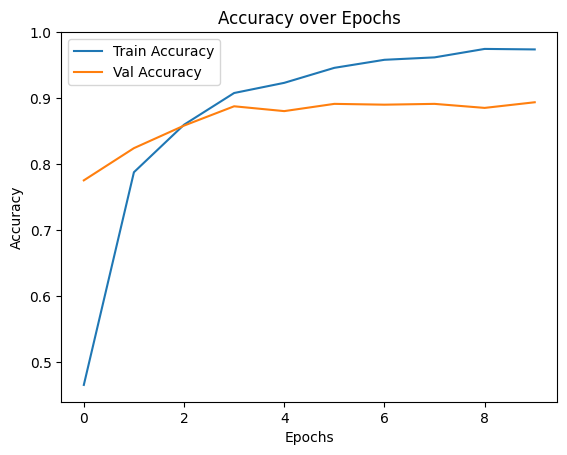

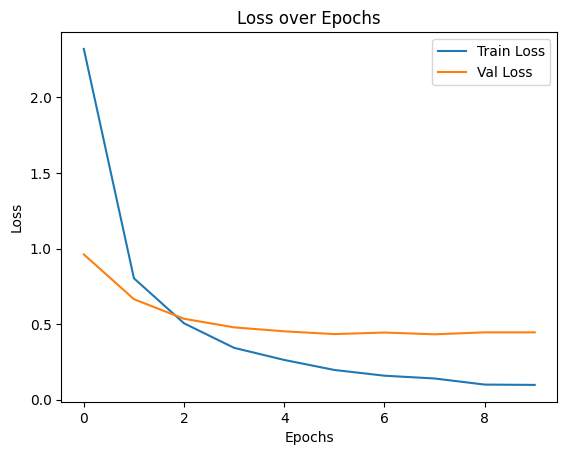

In [ ]:
#plotting training vs validation accuracy

plt.plot(history.history['accuracy'], label='Train Accuracy') #training accuracy per epoch
plt.plot(history.history['val_accuracy'], label='Val Accuracy') #validation accuracy per epoch

plt.legend() #to distinguish line
plt.title("Accuracy over Epochs") #to add graph title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.show() #to display the plot


#plotting training vs validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.legend()
plt.title("Loss over Epochs")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


In [ ]:
#generating predictions on the test set

#predicting probabilities for every test images in the test dataset
pred_probs = model.predict(test_gen) #output shape:(number_of_test_images, 102)

#converting predicted probabilities to actual class labels.
# For each image, argmax finds the index of the class with the highest probability.
pred_labels = np.argmax(pred_probs, axis=1)

# Extracting the true labels directly from the test generator and storing them.
true_labels = test_gen.classes

#True = correct, False = incorrect
correct_labels = pred_labels == true_labels
incorrect_labels = pred_labels != true_labels

# Counting how many were correct or incorrect
num_correct = np.sum(correct_labels)
num_incorrect = np.sum(incorrect_labels)

print('number of prdicted as true lable images',num_correct)
print('number of original true label images',num_incorrect)


26/26 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step
number of prdicted as true lable images 743
number of original true label images 76


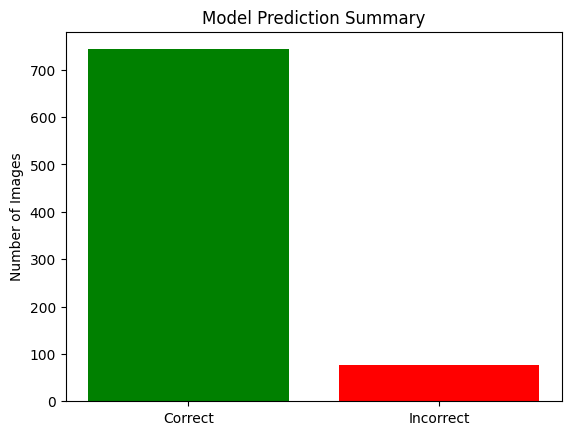

In [ ]:
#plotting correct prediction vs incorrect prediction barchart.


correct = sum(pred_labels == true_labels)
incorrect = len(true_labels) - correct

plt.bar(['Correct', 'Incorrect'], [correct, incorrect], color=['green', 'red'])
plt.title('Model Prediction Summary')
plt.ylabel('Number of Images')
plt.show()


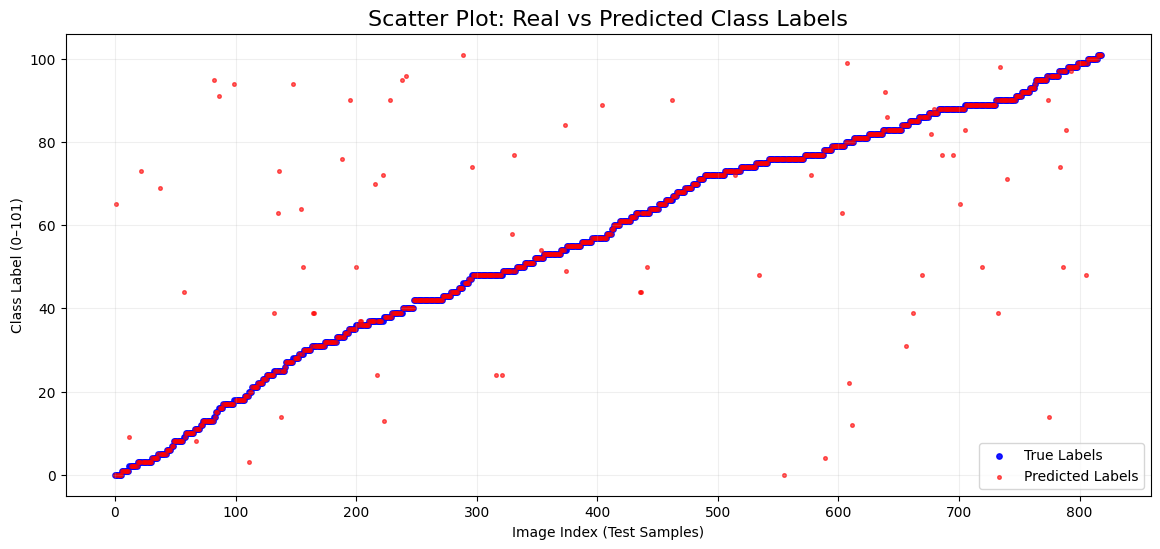

In [ ]:
#plotting a scatterplot between correct vs predicted labels



plt.figure(figsize=(14, 6))

#creating index of  test samples
x_axis = np.arange(len(true_labels))

#plotting TRUE labels (blue)
plt.scatter(x_axis, true_labels,
            color='blue', s=15, alpha=0.9, label="True Labels")

# plotting PREDICTED labels (red)
plt.scatter(x_axis, pred_labels,
            color='red', s=7, alpha=0.6, label="Predicted Labels")

plt.title("Scatter Plot: Real vs Predicted Class Labels", fontsize=16)
plt.xlabel("Image Index (Test Samples)")
plt.ylabel("Class Label (0–101)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


Here,
* x-axis= sample number
* y-axis= class ID
* blue= real labels
* red= predicted labels
* when red is far from blue= wrong,  On blue= correct


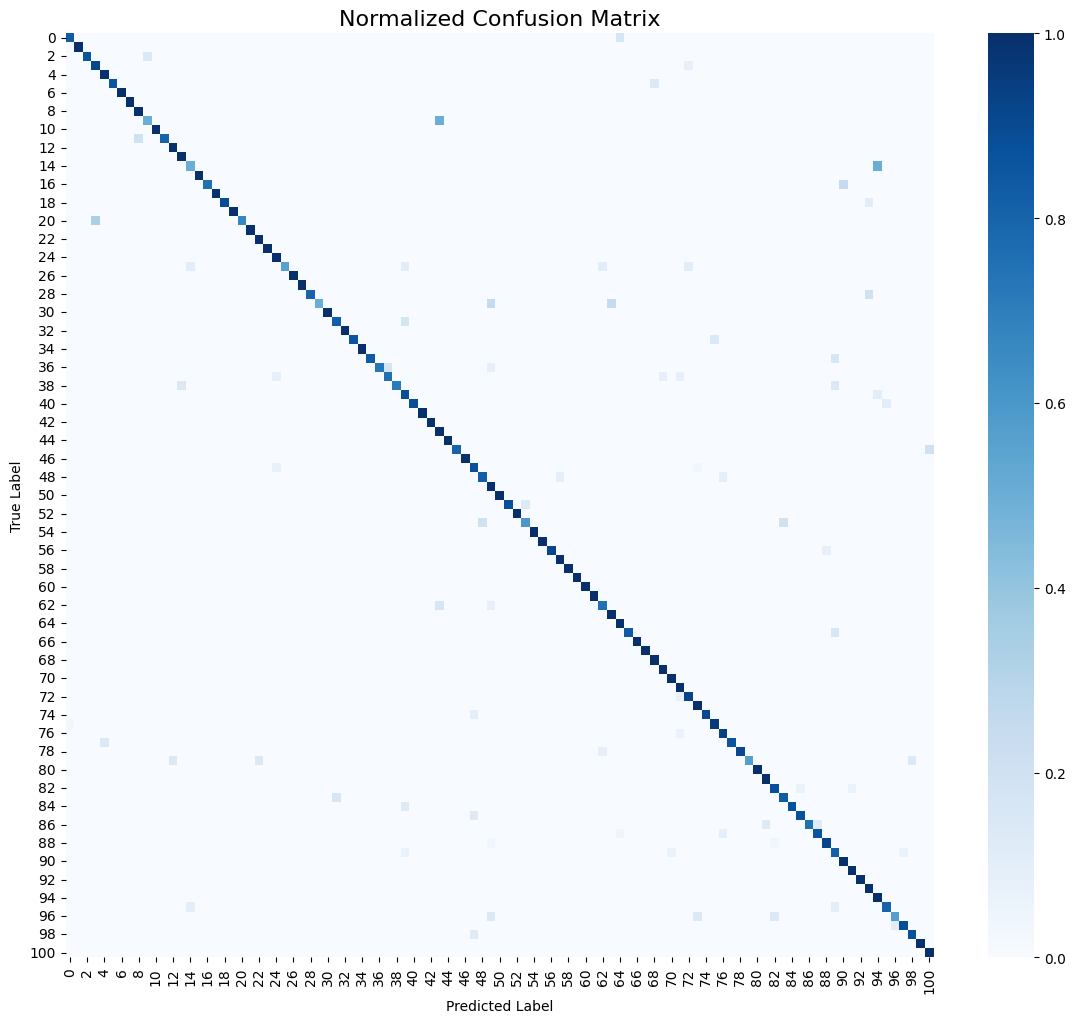

In [ ]:


cm = confusion_matrix(true_labels, pred_labels)

# Normalizing the matrix to scale values between 0 and 1
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, cmap='Blues', cbar=True)

plt.title("Normalized Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


**Since there are 102 classes,
each row represents the true class and each column represents the predicted class.**
* Dark blue diagonal = correct predictions
* Light dots off the diagonal = misclassifications. Only a few faint off-diagonal points are visible, showing that misclassifications are minimal and distributed sparsely across classes

In [ ]:
# evaluating based on more parameters

print(classification_report(true_labels, pred_labels))


              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       1.00      1.00      1.00         6
           2       1.00      0.86      0.92         7
           3       0.92      0.92      0.92        12
           4       0.83      1.00      0.91         5
           5       1.00      0.86      0.92         7
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         2
           8       0.89      1.00      0.94         8
           9       0.50      0.50      0.50         2
          10       1.00      1.00      1.00         7
          11       1.00      0.80      0.89         5
          12       0.67      1.00      0.80         2
          13       0.90      1.00      0.95         9
          14       0.33      0.50      0.40         2
          15       1.00      1.00      1.00         2
          16       1.00      0.75      0.86         4
          17       1.00    

**These results confirm the reliability and generalisation capability of the CNN architecture used in this study**

In [ ]:
model.save("flowers_mobilenetv2.h5")
print("Model saved successfully!")


Model saved successfully!


In [ ]:
#deploying
import streamlit as st
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import PIL as Image
import os

#loading the model
model = load_model('flowers_mobilenetv2.h5')

#class names(0-101)
class_names=[str(i) for i in range(102)]

st.title("Flower classifier (MobileNetV2)")
st.write("Upload an image to classify the flower type:")

uploaded_file=st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
  #displaying the uploaded image
  image=Image.open(uploaded_file).convert("RGB")
  st.image(image, caption="Uploaded Image", use_column_width=True)

  #preprocessing
  img = img.resize((224, 224))
  img_array = image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)
  img_array = img_array / 255.0

  # Prediction
  pred = model.predict(img_array)
  class_id = np.argmax(pred)
  confidence = np.max(pred) * 100

  st.write(f"### Predicted Class: **{class_names[class_id]}**")
  st.write(f"### Confidence: **{confidence:.2f}%**")


ModuleNotFoundError: No module named 'streamlit'